In [2]:
import pandas as pd
# Load dataset
df = pd.read_csv("/content/sample_data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.00

In [ ]:
print("\nOutcome Counts:")
print(df["Outcome"].value_counts())


Outcome Counts:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
zero_counts = (df == 0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [3]:
cols_with_invalid_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[cols_with_invalid_zero] = df[cols_with_invalid_zero].replace(0, pd.NA)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,<NA>,33.6,0.627,50,1
1,1,85,66,29,<NA>,26.6,0.351,31,0
2,8,183,64,<NA>,<NA>,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,<NA>,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,<NA>,<NA>,30.1,0.349,47,1


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


In [7]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

Missing values in X_test:
Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64


In [8]:
import numpy as np
import pandas as pd

X_train = X_train.replace(pd.NA, np.nan)
X_test = X_test.replace(pd.NA, np.nan)

/tmp/ipykernel_920/925144993.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = X_train.replace(pd.NA, np.nan)
/tmp/ipykernel_920/925144993.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test = X_test.replace(pd.NA, np.nan)


In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [10]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in X_test:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nFirst 5 rows of scaled training data:")
print(X_train_scaled[:5])

X_train_scaled shape: (614, 8)
X_test_scaled shape: (154, 8)

First 5 rows of scaled training data:
[[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76969431
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41771394
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.35957603
  -0.76486207 -0.70759409]
 [-0.85135507  0.81152492 -1.31593218 -0.00476614 -0.16143729 -0.40304809
   0.26231357 -0.36929331]
 [-1.15333775 -0.88964601 -0.66367599  1.12077551 -0.41556496  1.78216334
  -0.33762972 -0.96131967]]


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier( n_estimators=100,random_state=42),
    "SVM": SVC( kernel="rbf", C=1.0,gamma="scale")
}

In [15]:
results = {}

for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc*100:.2f} %")
    print(classification_report(y_test, preds))




Logistic Regression Accuracy: 70.78 %
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Decision Tree Accuracy: 68.18 %
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154


Random Forest Accuracy: 76.62 %
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75

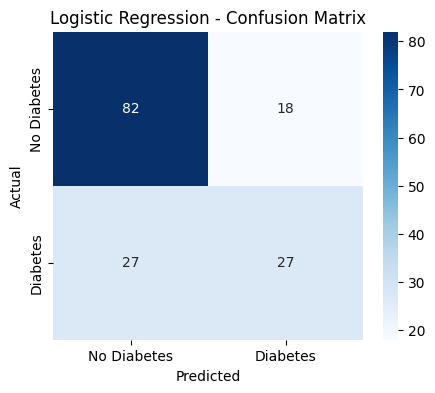

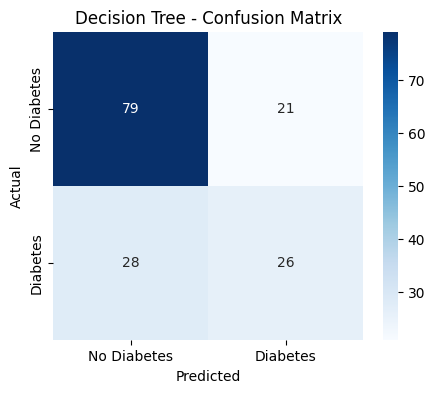

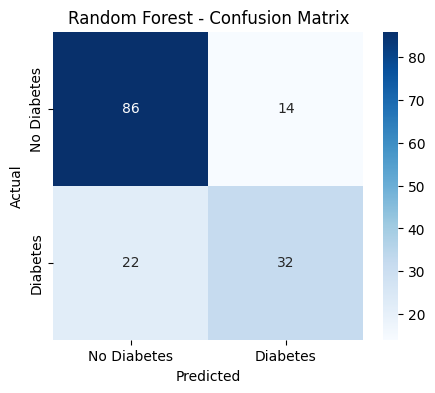

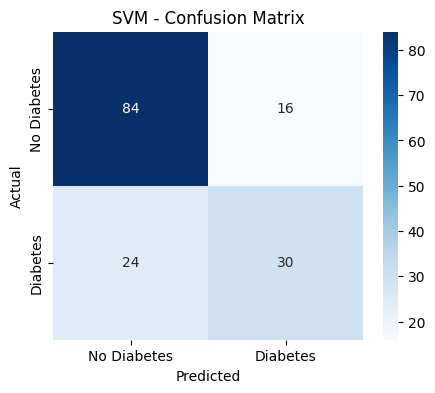

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix Heatmap for each model

for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, preds)

    # Heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Diabetes", "Diabetes"],
        yticklabels=["No Diabetes", "Diabetes"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [25]:
y_pred = models["Random Forest"].predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nIndividual Values:")
print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

# Validation
total = tn + fp + fn + tp

print("\nValidation:")
print("Total test samples:", len(y_test))
print("TN + FP + FN + TP:", total)

# Manually calculate accuracy
manual_accuracy = (tn + tp) / total

print("Manual Accuracy:", manual_accuracy)
print("Manual Accuracy (%):", manual_accuracy * 100)

# Compare with sklearn accuracy
sklearn_accuracy = accuracy_score(y_test, y_pred)

print("\nSklearn Accuracy:", sklearn_accuracy)
print("Sklearn Accuracy (%):", sklearn_accuracy * 100)

Confusion Matrix:
[[86 14]
 [22 32]]

Individual Values:
True Negative (TN): 86
False Positive (FP): 14
False Negative (FN): 22
True Positive (TP): 32

Validation:
Total test samples: 154
TN + FP + FN + TP: 154
Manual Accuracy: 0.7662337662337663
Manual Accuracy (%): 76.62337662337663

Sklearn Accuracy: 0.7662337662337663
Sklearn Accuracy (%): 76.62337662337663


In [26]:
print("Count of 0 (No Diabetes):", (y_test == 0).sum())
print("Count of 1 (Diabetes):", (y_test == 1).sum())

Count of 0 (No Diabetes): 100
Count of 1 (Diabetes): 54


In [17]:
print("\nModel Comparison:")
for name, acc in results.items():
    print(f"{name}: {acc:.2f}")


Model Comparison:
Logistic Regression: 0.71
Decision Tree: 0.68
Random Forest: 0.77
SVM: 0.74


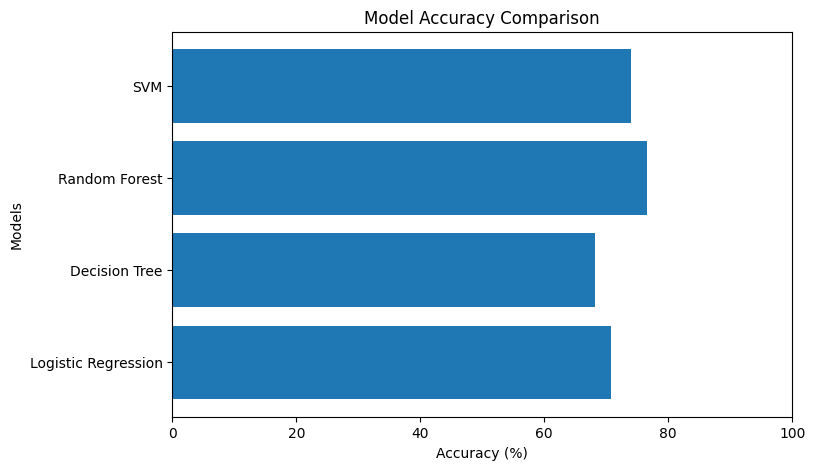

In [18]:
plt.figure(figsize=(8, 5))
plt.barh(
    list(results.keys()),
    [acc * 100 for acc in results.values()]
)
plt.xlabel("Accuracy (%)")
plt.ylabel("Models")

plt.title("Model Accuracy Comparison")

plt.xlim(0, 100)

plt.show()

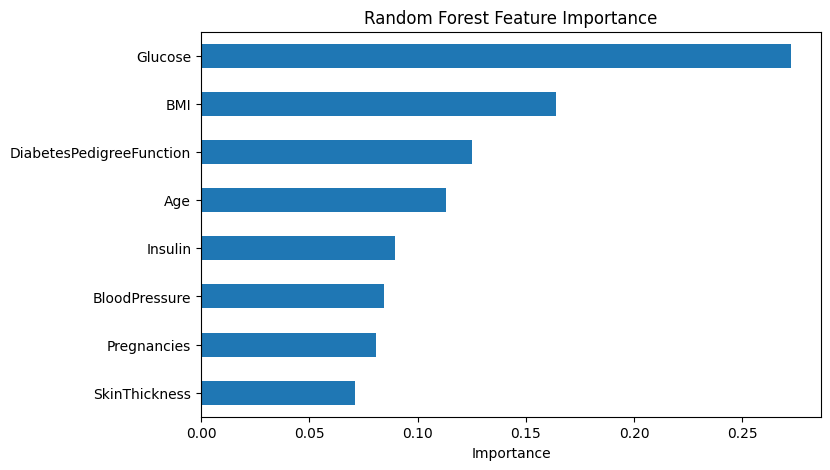

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
     models["Random Forest"].feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
# Hyperparameter Tuning - Random Forest

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="accuracy"
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

rf_predictions = best_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nTuned Random Forest Test Accuracy:")
print(rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Best Random Forest Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.7769159003065441

Tuned Random Forest Test Accuracy:
0.7532467532467533

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [22]:
# Hyperparameter Tuning - SVM

svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_param_grid,
    cv=5,
    scoring="accuracy"
)

svm_grid.fit(X_train_scaled, y_train)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(svm_grid.best_score_)

best_svm = svm_grid.best_estimator_

svm_predictions = best_svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("\nTuned SVM Test Accuracy:")
print(svm_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))

Best SVM Parameters:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best Cross-Validation Accuracy:
0.7752765560442489

Tuned SVM Test Accuracy:
0.6948051948051948

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       100
           1       0.58      0.46      0.52        54

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154



In [23]:
tuned_results = {
    "Original Random Forest": results["Random Forest"],
    "Original SVM": results["SVM"],
    "Tuned Random Forest": rf_accuracy,
    "Tuned SVM": svm_accuracy
}

print("Tuned Model Comparison:\n")

for name, accuracy in tuned_results.items():
    print(f"{name}: {accuracy*100:.4f}")

Tuned Model Comparison:

Original Random Forest: 76.6234
Original SVM: 74.0260
Tuned Random Forest: 75.3247
Tuned SVM: 69.4805


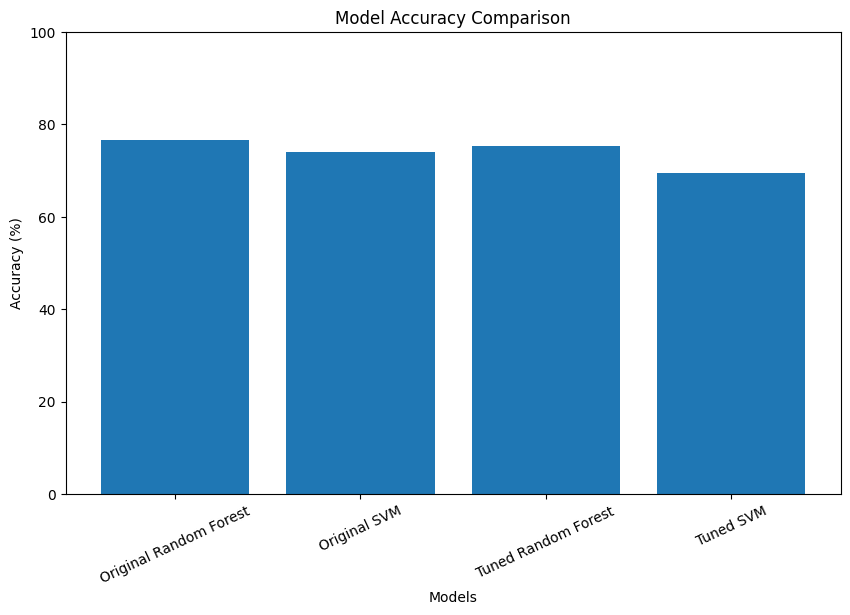

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    tuned_results.keys(),
    [acc * 100 for acc in tuned_results.values()]
)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=25)
plt.ylim(0, 100)

plt.show()

In [28]:
print("Enter patient details:")

pregnancies = float(input("Pregnancies: "))
glucose = float(input("Glucose: "))
blood_pressure = float(input("BloodPressure: "))
skin_thickness = float(input("SkinThickness: "))
insulin = float(input("Insulin: "))
bmi = float(input("BMI: "))
diabetes_pedigree = float(input("DiabetesPedigreeFunction: "))
age = float(input("Age: "))

new_patient = pd.DataFrame([[
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
]], columns=X.columns)

# Convert 0 to missing values for the medical columns
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

new_patient[medical_columns] = new_patient[medical_columns].replace(0, np.nan)

# Use the SAME median values used for training
new_patient[medical_columns] = new_patient[medical_columns].fillna(
    X_train[medical_columns].median()
)

# Predict using Random Forest
prediction = best_rf=.predict(new_patient)

if prediction[0] == 1:
    print("\nPrediction: Diabetes")
else:
    print("\nPrediction: No Diabetes")

Enter patient details:
Pregnancies: 1
Glucose: 80
BloodPressure: 89
SkinThickness: 56
Insulin: 0
BMI: 33.6
DiabetesPedigreeFunction: 0.25
Age: 30

Prediction: No Diabetes


 Add Linear Regression on a separate regression dataset (e.g., predict BMI or glucose level as a
continuous value instead of classifying diabetes

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Create a copy of the dataset
regression_df = df.copy()

# Remove rows where BMI is missing
regression_df = regression_df.dropna(subset=["BMI"])

# Features
X_reg = regression_df[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "Age",
        "DiabetesPedigreeFunction"
    ]
]

# Target
y_reg = regression_df["BMI"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (768, 7)
y shape: (768,)


In [ ]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin"
]

X_reg[medical_columns] = X_reg[medical_columns].replace(0, np.nan)

X_reg = X_reg.fillna(X_reg.median())

print("Missing values:")
print(X_reg.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
Age                         0
DiabetesPedigreeFunction    0
dtype: int64


In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:", X_test_reg.shape)
print("y_train:", y_train_reg.shape)
print("y_test:", y_test_reg.shape)

X_train: (614, 7)
X_test: (154, 7)
y_train: (614,)
y_test: (154,)


In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

LinearRegression()

In [ ]:
y_pred_reg = linear_model.predict(X_test_reg)

print("First 10 actual BMI values:")
print(y_test_reg.head(10).values)

print("\nFirst 10 predicted BMI values:")
print(y_pred_reg[:10])

First 10 actual BMI values:
[34.  35.7 30.8 24.6 29.9 37.7 20.4 33.8 31.3 33.7]

First 10 predicted BMI values:
[30.88550528 33.97771661 31.49606449 32.78290445 32.34373815 30.64646565
 23.74159627 31.18989022 32.6060755  30.03867832]


In [ ]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg, y_pred_reg)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 5.236838257215836
MSE : 61.56599150077674
RMSE: 7.846399907013199
R²  : 0.13391564710644377


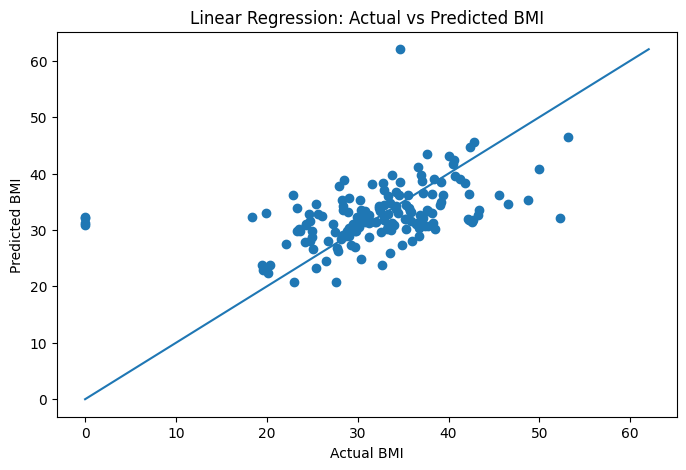

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test_reg, y_pred_reg)

# Ideal prediction line
min_value = min(y_test_reg.min(), y_pred_reg.min())
max_value = max(y_test_reg.max(), y_pred_reg.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Linear Regression: Actual vs Predicted BMI")

plt.show()

In [ ]:
print("Enter patient details:")

pregnancies = float(input("Pregnancies: "))
glucose = float(input("Glucose: "))
blood_pressure = float(input("BloodPressure: "))
skin_thickness = float(input("SkinThickness: "))
insulin = float(input("Insulin: "))
age = float(input("Age: "))
diabetes_pedigree = float(input("DiabetesPedigreeFunction: "))

new_patient = pd.DataFrame([[
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    age,
    diabetes_pedigree
]], columns=X_reg.columns)

# Replace invalid zero values with NaN
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin"
]

new_patient[medical_columns] = new_patient[medical_columns].replace(0, np.nan)

# Fill missing values using training data medians
new_patient[medical_columns] = new_patient[medical_columns].fillna(
    X_train_reg[medical_columns].median()
)

# Predict BMI
predicted_bmi = linear_model.predict(new_patient)

print("\nPredicted BMI:", predicted_bmi[0])

Enter patient details:
Pregnancies: 6
Glucose: 148
BloodPressure: 72
SkinThickness: 35
Insulin: 0
Age: 50
DiabetesPedigreeFunction: 0.6

Predicted BMI: 34.09900470737414
